# Tarea 2 – Modelos de Datos de Panel

**Javiera Rivas Parra**

En esta tarea estudio cómo las restricciones que aplicaron los gobiernos durante la pandemia afectaron la movilidad de las personas para ir a trabajar. Para ello uso datos semanales de ciudades de España, Francia, Italia y Suecia. 

** Siguiendo lo hablado en la clase online, se excluyo Alemania porque sus datos de restricciones presentan ceros anómalos que no reflejan la política real implementada.  (Antes realice la pregunta 1 incluyendo alemania y note que los graficos estaban extraños por lo que me acordé de la clase y mejor los deje como están actualmente jeje)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
import linearmodels.panel as lmp
from linearmodels.panel import compare
from scipy.stats import chi2
import numpy.linalg as nla
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.



### Pregunta 1: Carga, Exploración y Limpieza de Datos

*Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.*

In [2]:
# Carga y exploración inicial del dataset
df_raw = pd.read_csv("dataset_prueba.csv")
print(f"Dimensiones originales: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
print(f"Países en dataset: {list(df_raw['country'].unique())}")

# Excluimos ciudades alemanas (datos de restricciones anómalos segun lo comentado en clases)
df = df_raw[df_raw["country"] != "DE"].copy()
print(f"\nDimensiones sin Alemania: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Países restantes: {list(df['country'].unique())}")
print(f"Ciudades únicas: {df['CODE'].nunique()}")
df.head()

Dimensiones originales: 12040 filas x 41 columnas
Países en dataset: ['DE', 'ES', 'FR', 'IT', 'SE']

Dimensiones sin Alemania: 6580 filas x 41 columnas
Países restantes: ['ES', 'FR', 'IT', 'SE']
Ciudades únicas: 47


,iso_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,...,edu3,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners,country
5460,ES-A,2020-02-17,0.0,2.0,9.0,7.0,3.0,0.0,2.409706,0.641249,...,0.486567,0.629075,0.324359,0.304716,106.556293,21.0,0.211359,0.211400,12.0,ES
5461,ES-A,2020-02-17,0.0,2.0,9.0,7.0,3.0,0.0,2.409706,0.641249,...,0.339541,0.602564,0.338330,0.264235,101.712405,25.0,0.216168,0.289162,8.0,ES
5462,ES-A,2020-02-24,-0.2,0.4,9.0,4.4,1.2,0.0,-1.897601,-0.695795,...,0.486567,0.629075,0.324359,0.304716,106.556293,21.0,0.211359,0.211400,12.0,ES
5463,ES-A,2020-02-24,-0.2,0.4,9.0,4.4,1.2,0.0,-1.897601,-0.695795,...,0.339541,0.602564,0.338330,0.264235,101.712405,25.0,0.216168,0.289162,8.0,ES
5464,ES-A,2020-03-02,0.4,3.6,15.0,6.4,2.6,0.0,-10.765587,-4.537905,...,0.486567,0.629075,0.324359,0.304716,106.556293,21.0,0.211359,0.211400,12.0,ES


In [ ]:
# Revisamos tipos de datos y cantidad de columnas por tipo 
print("=== Tipos de datos por columna ===")
print(df.dtypes)
print(f"\nNuméricas: {df.select_dtypes(include=np.number).shape[1]}")
print(f"String/obj: {df.select_dtypes(include='object').shape[1]}")

=== Tipos de datos por columna ===
iso_code                                               object
date                                                   object
retail_and_recreation_percent_change_from_baseline    float64
grocery_and_pharmacy_percent_change_from_baseline     float64
parks_percent_change_from_baseline                    float64
transit_stations_percent_change_from_baseline         float64
workplaces_raw                                        float64
residential_percent_change_from_baseline              float64
trend                                                 float64
workplaces                                            float64
Valor_Stringency_Index                                float64
Valor_GovernmentResponseIndex                         float64
Valor_EconomicSupportIndex                            float64
Valor_Containment_Health_index                        float64
workplace_closing                                     float64
daily_cases                        

Las columnas d1 a d6, no se encuentran definidas en el diccionario proporcionado, por lo que serán excluidas del análisis. Además, la columna de fecha está almacenada como string y se convertirá a formato datetime.

In [4]:
# CONVERSIÓN DE FECHAS Y ANÁLISIS DE VALORES FALTANTES

# Convertir 'date' a datetime
df["date"] = pd.to_datetime(df["date"])
missing = df.isnull().sum() # Conteo de valores faltantes por columna
missing_pct = (missing / len(df) * 100).round(2) # Porcentaje de valores faltantes
missing_df = pd.DataFrame({"N faltantes": missing, "% faltantes": missing_pct}) # DataFrame resumen de faltantes
report = missing_df[missing_df["N faltantes"] > 0].sort_values("% faltantes", ascending=False)
print("=== Variables con datos faltantes ===")
print(report.to_string() if not report.empty else "Sin valores faltantes.")

=== Variables con datos faltantes ===
Sin valores faltantes.


In [5]:
# información general del dataset
print(f"Ciudades únicas: {df['CODE'].nunique()}")
print(f"Rango fechas: {df['date'].min().date()} a {df['date'].max().date()}")
print(f"Semanas únicas: {df['week'].nunique()}")
print(f"Países: {list(df['country'].unique())}")

Ciudades únicas: 47
Rango fechas: 2020-02-17 a 2022-10-17
Semanas únicas: 140
Países: ['ES', 'FR', 'IT', 'SE']


#### Estadísticas descriptivas de variables clave

Se describen las variables que se consideran más relevantes para la pregunta de investigación, que son las asociadas a las restricciones gubernamentales, el miedo al virus (casos), al comportamiento de movilidad de las personas y variables de control económico y sociodemográfico (población, edad, desempleo).

In [6]:
vars_interest = [
    "workplaces_raw", "Valor_Stringency_Index",
    "workplace_closing", "daily_cases", "Population",
    "residential_percent_change_from_baseline",
    "transit_stations_percent_change_from_baseline",
    "retail_and_recreation_percent_change_from_baseline",
    "unemp", "age_dependency"
]
vars_interest = [v for v in vars_interest if v in df.columns]
print("=== Estadísticas Descriptivas – Variables Clave (sin Alemania) ===")
df[vars_interest].describe().round(2)

=== Estadísticas Descriptivas – Variables Clave (sin Alemania) ===


,workplaces_raw,Valor_Stringency_Index,workplace_closing,daily_cases,Population,residential_percent_change_from_baseline,transit_stations_percent_change_from_baseline,retail_and_recreation_percent_change_from_baseline,unemp,age_dependency
count,6580.00,6580.00,6580.00,6580.00,6580.00,6580.00,6580.00,6580.00,6580.00,6580.00
mean,-26.45,50.29,1.56,2549.88,918.75,7.00,-16.03,-17.15,17.57,0.69
std,15.90,21.95,0.85,3429.82,1615.08,7.07,27.97,23.28,7.76,0.07
min,-87.00,5.56,0.00,0.00,201.49,-3.80,-88.60,-95.60,6.00,0.55
25%,-34.40,35.51,1.00,0.04,253.67,2.40,-32.00,-27.60,12.00,0.63
50%,-23.80,49.78,2.00,851.94,378.80,5.00,-16.40,-12.60,17.00,0.67
75%,-14.80,68.52,2.00,4304.18,787.52,9.20,-1.00,-3.00,24.00,0.73
max,6.60,93.52,3.00,22203.31,10274.88,42.60,123.20,70.40,36.00,0.84


#### Distribuciones y outliers

Se muestran las variables que podrian variar producto a la pandemia. 
Por un lado, la movilidad (laboral, residencial y de tránsito) refleja el cambio en el comportamiento de las personas hacia el resguardo en casa, mientras que el índice de Stringency captura cómo las políticas gubernamentales forzaron esos cambios. Los casos diarios sirven como proxy del miedo al contagio.

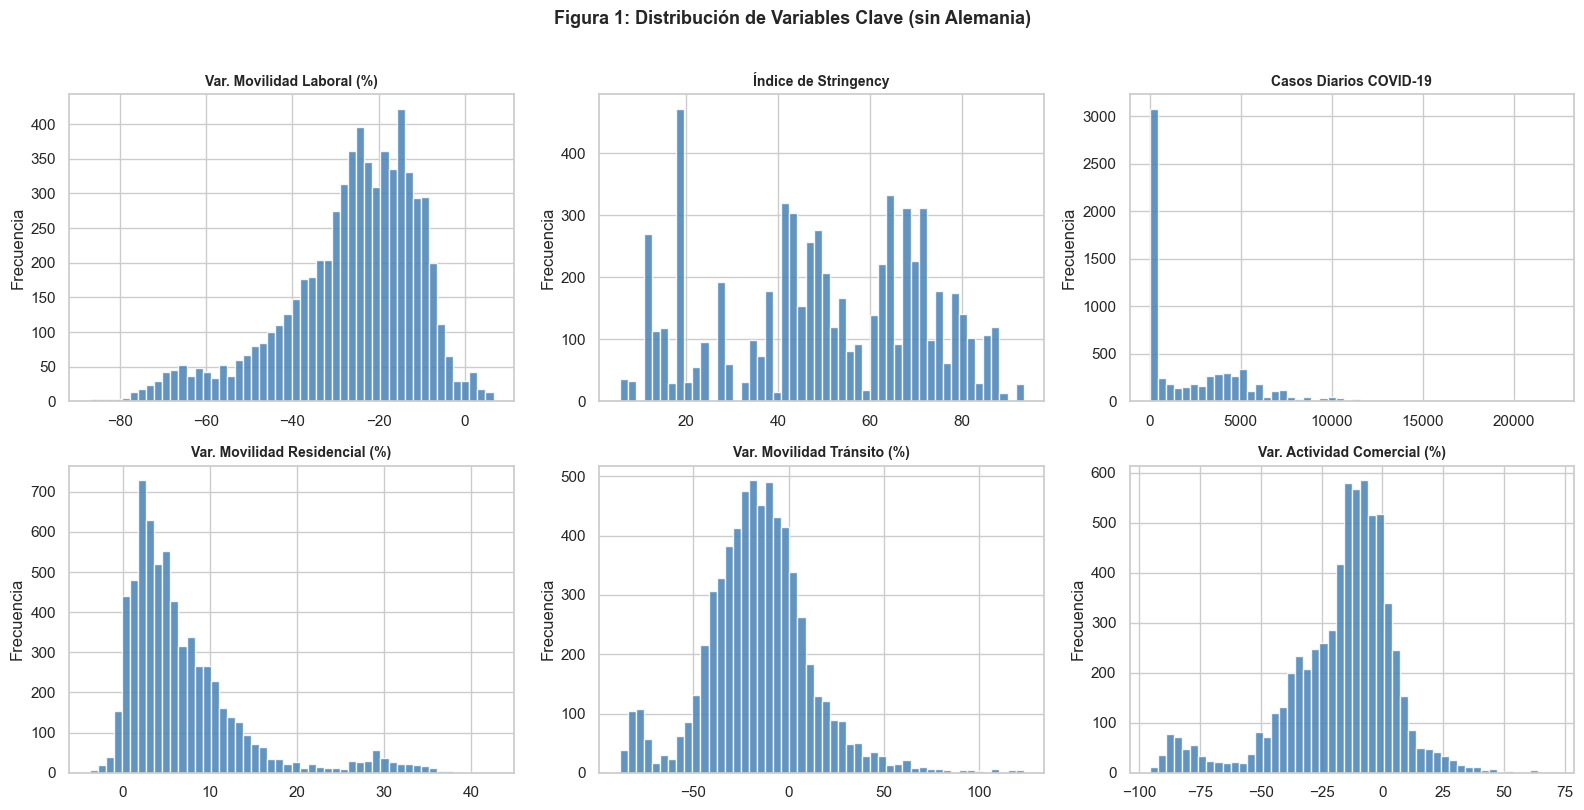

In [7]:
# Visualización de distribuciones para variables clave
plot_vars = [
    ("workplaces_raw", "Var. Movilidad Laboral (%)"),
    ("Valor_Stringency_Index", "Índice de Stringency"),
    ("daily_cases", "Casos Diarios COVID-19"),
    ("residential_percent_change_from_baseline", "Var. Movilidad Residencial (%)"),
    ("transit_stations_percent_change_from_baseline", "Var. Movilidad Tránsito (%)"),
    ("retail_and_recreation_percent_change_from_baseline", "Var. Actividad Comercial (%)"),
]
plot_vars = [(v, l) for v, l in plot_vars if v in df.columns]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, (var, label) in enumerate(plot_vars):
    axes[i].hist(df[var].dropna(), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(label, fontsize=10, fontweight="bold")
    axes[i].set_ylabel("Frecuencia")
for j in range(len(plot_vars), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Figura 1: Distribución de Variables Clave (sin Alemania)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

Los gráficos de movilidad laboral y actividad comercial presentan distribuciones sesgadas hacia valores negativos, es decir, ambas sufrieron una caída sostenida respecto a la línea base. Por otro lado, la movilidad residencial aumentó, lo que es consistente con que las personas permanecieran más tiempo en sus hogares.

Las políticas gubernamentales muestran alta variación (distribución amplia del Stringency Index), y los casos diarios presentan fuerte asimetría a la derecha: la mayoría de las semanas registraron pocos casos, con olas esporádicas de alta transmisión.

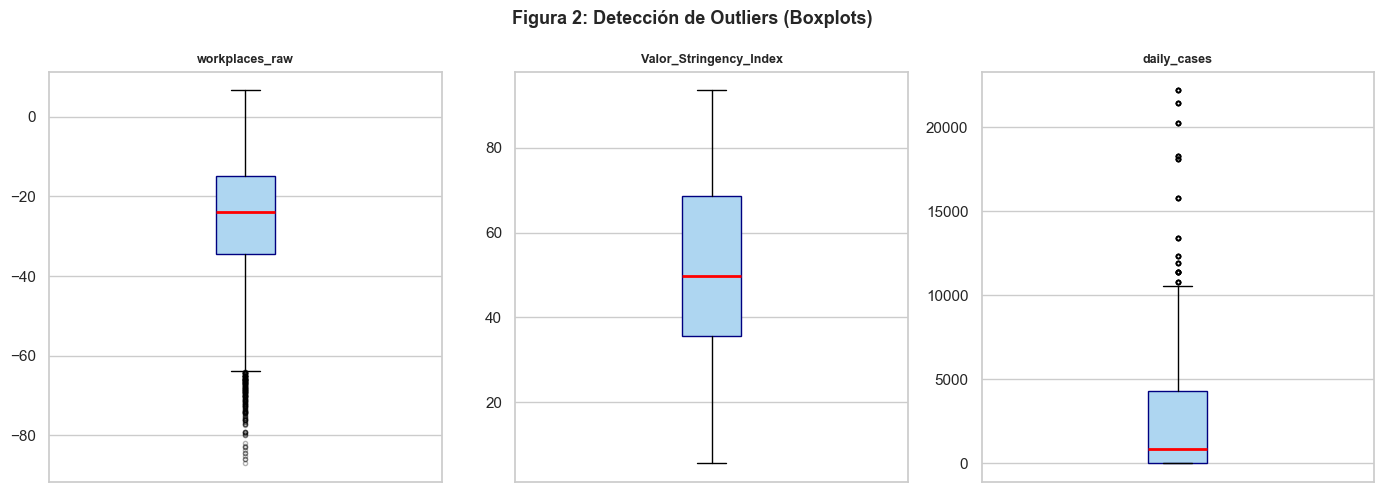

In [8]:
# Detección de outliers con boxplots
box_vars = [v for v in ["workplaces_raw", "Valor_Stringency_Index", "daily_cases"] if v in df.columns]
fig, axes = plt.subplots(1, len(box_vars), figsize=(14, 5))
for ax, var in zip(axes, box_vars):
    ax.boxplot(df[var].dropna(), patch_artist=True,
               boxprops=dict(facecolor="#AED6F1", color="navy"),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker="o", color="gray", alpha=0.3, markersize=3))
    ax.set_title(var, fontsize=9, fontweight="bold"); ax.set_xticks([])
plt.suptitle("Figura 2: Detección de Outliers (Boxplots)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


En los boxplots se observa que los valores extremos de movilidad laboral corresponden a períodos de cuarentenas totales, por lo que no representan errores de medición sino eventos reales de alta restricción.

El índice de Stringency no presenta outliers (es un índice acotado entre 0 y 100), pero su caja es amplia, lo que confirma que las políticas variaron considerablemente a lo largo del período analizado.

Los casos diarios muestran una caja concentrada en valores bajos, pero con outliers notables que corresponden a las grandes olas de contagio. Para evitar que estos valores extremos distorsionen los estimadores de la regresión, se aplica una winsorización al percentil 99 en la variable `cases_per_100k`.

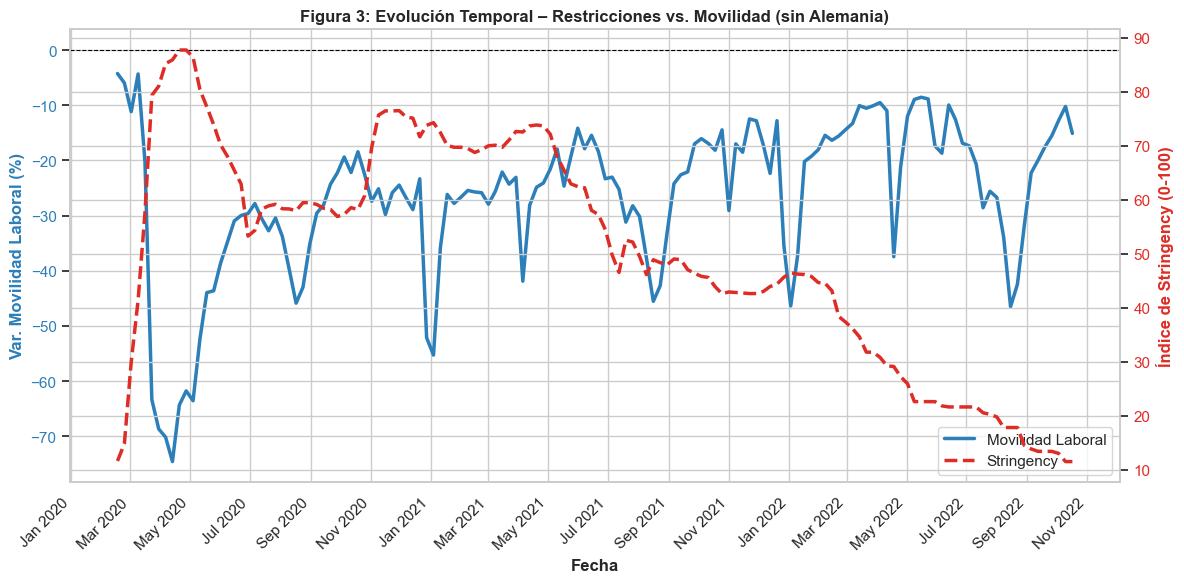

In [9]:
#Análisis de Tendencia Temporal entre Políticas y Comportamiento

weekly = df.groupby("date")[["workplaces_raw","Valor_Stringency_Index"]].mean().reset_index() 
fig, ax1 = plt.subplots(figsize=(12, 6))
c1, c2 = "#2c7fb8", "#de2d26"
ax1.set_xlabel("Fecha", fontweight="bold")
ax1.set_ylabel("Var. Movilidad Laboral (%)", color=c1, fontweight="bold")
l1 = ax1.plot(weekly["date"], weekly["workplaces_raw"], color=c1, linewidth=2.5, label="Movilidad Laboral")
ax1.tick_params(axis="y", labelcolor=c1)
ax1.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax2 = ax1.twinx()
ax2.set_ylabel("Índice de Stringency (0-100)", color=c2, fontweight="bold")
l2 = ax2.plot(weekly["date"], weekly["Valor_Stringency_Index"], color=c2, linewidth=2.5, linestyle="--", label="Stringency")
ax2.tick_params(axis="y", labelcolor=c2)
lines = l1+l2
ax1.legend(lines, [l.get_label() for l in lines], loc="lower right")
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")
plt.title("Figura 3: Evolución Temporal – Restricciones vs. Movilidad (sin Alemania)", fontsize=12, fontweight="bold")
fig.tight_layout(); plt.show()

Al observar la evolución temporal, se aprecia que al inicio del período, aun antes de que se formalizaran las políticas, la movilidad laboral ya estaba cayendo, posiblemente por comportamiento preventivo espontáneo de la población. Luego, cuando las restricciones aumentan, la movilidad cae a su nivel mínimo, evidenciando el impacto de los primeros confinamientos totales.

En el tramo central del gráfico se confirma la relación inversa entre ambas variables: a mayor Stringency, menor movilidad laboral. Hacia el final del período, la movilidad se recupera lentamente incluso cuando las restricciones disminuyen, lo que podría reflejar la adopción permanente del teletrabajo o cambios en los hábitos laborales.

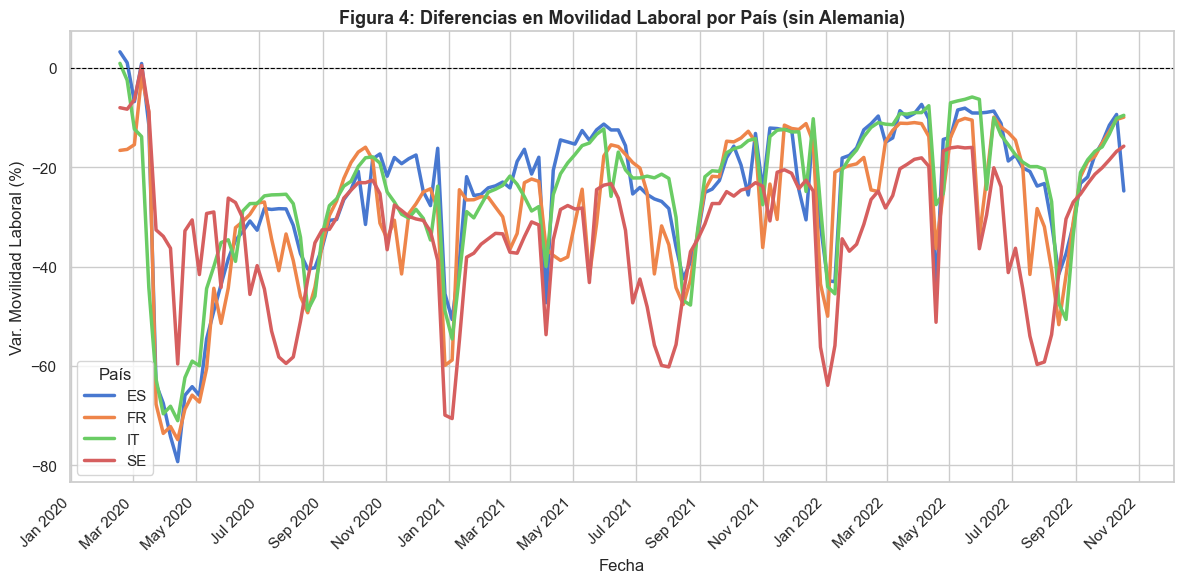

In [10]:
#Diferencias en movilidad laboral por país (sin Alemania)

trend = df.groupby(["date","country"])["workplaces_raw"].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=trend, x="date", y="workplaces_raw", hue="country", linewidth=2.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Figura 4: Diferencias en Movilidad Laboral por País (sin Alemania)", fontsize=13, fontweight="bold")
plt.xlabel("Fecha"); plt.ylabel("Var. Movilidad Laboral (%)")
plt.legend(title="País"); plt.tight_layout(); plt.show()

Al inicio (entre marzo y mayo de 2020) la movilidad laboral cae drásticamente por las cuarentenas iniciales de la pandemia. Luego se observan picos hacia abajo a mediados de año; en Europa las vacaciones de verano ocurren en agosto y las personas tienden a tomarse el mes completo, lo que explicaría esa fuerte caída estacional. Los otros picos coinciden con enero, explicados por los días libres de Navidad y Año Nuevo.

Se observan también diferencias entre países: Italia y España muestran caídas iniciales más pronunciadas (confinamientos estrictos), mientras que Suecia presenta menor variación, consistente con su política de restricciones más laxas. A pesar de las caídas estacionales, la tendencia general de la movilidad laboral es de lenta recuperación a lo largo del tiempo.

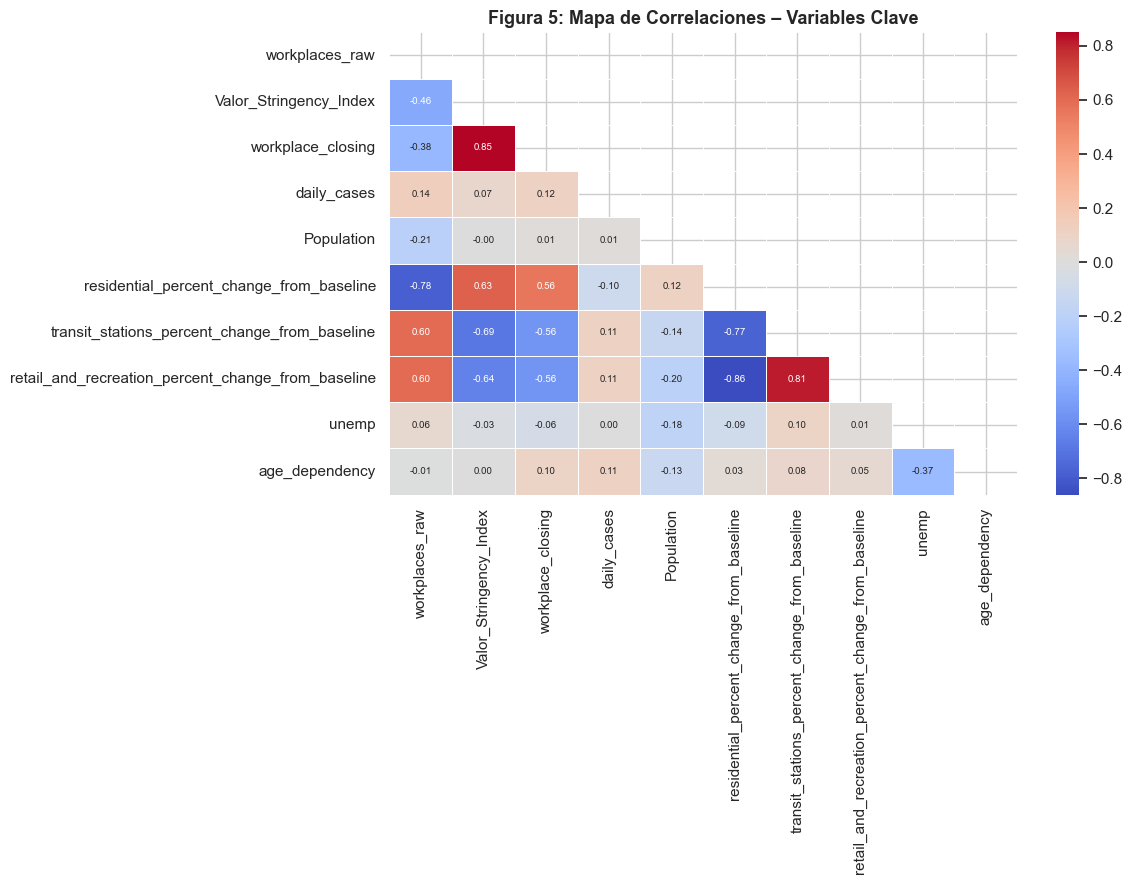

In [11]:
#mapa de correlaciones para variables clave

corr_matrix = df[vars_interest].corr().round(2)
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,
            annot_kws={"size": 7}, mask=mask)
plt.title("Figura 5: Mapa de Correlaciones – Variables Clave", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

La correlación negativa más destacada es la que existe entre la movilidad residencial (`residential_percent_change`) y la movilidad laboral (`workplaces_raw`): a medida que cae la asistencia presencial al trabajo, aumenta el tiempo que las personas pasan en casa, relación que es prácticamente mecánica.

Lo más llamativo es que los casos diarios presentan correlaciones bajas con las demás variables. Esto sugiere que el comportamiento de las personas respondió principalmente a las restricciones formales impuestas por los gobiernos, y no tanto al nivel de contagio observado directamente. Las políticas fueron el canal dominante, no el miedo al virus por sí solo.

### Limpieza y Construcción del Panel

Para estudiar cómo las restricciones gubernamentales afectaron la movilidad laboral durante la pandemia, necesitamos construir un panel de datos que capture tanto el comportamiento de las personas como el contexto en que ocurrió.

Nuestra variable dependiente es la movilidad laboral (workplaces_raw), ya que es el reflejo más directo de si las personas pudieron o decidieron ir a trabajar. Para explicarla, escogemos variables que representan tres fuerzas distintas que la afectaron:

- Las políticas del gobierno (Valor_Stringency_Index, workplace_closing), que miden cuán estrictas fueron las reglas impuestas.
- El contexto médico (cases_per_100k), que captura el miedo al contagio y la gravedad de cada ola pandémica.
- El comportamiento general de movilidad (residential, transit, retail), que nos muestra si el efecto fue solo en el trabajo o en toda la actividad de las personas.
- Las características socioeconómicas (unemp, age_dependency, foreigners), que controlan por las diferencias estructurales entre ciudades, evitando atribuir al COVID efectos que en realidad se explican por las condiciones propias de cada lugar.

Adicionalmente, para asegurar una comparación justa entre regiones de distinto tamaño, los contagios diarios se normalizaron como casos por cada 100.000 habitantes. Se aplicó además un recorte al percentil 99 para evitar que las olas extremas de contagio distorsionen los estimadores de la regresión.

In [12]:
# Preparación del panel para modelado

# Se eliminan filas con datos faltantes en variables clave
df = df.dropna(subset=["CODE", "date", "workplaces_raw", "Valor_Stringency_Index"]) 

# Se crea variable de casos por 100k habitantes para controlar efectos de la pandemia
df["cases_per_100k"] = (df["daily_cases"] / df["Population"]) * 100_000
df["cases_per_100k"] = df["cases_per_100k"].clip(lower=0)

# Se limita el impacto de outliers en casos por 100k usando el percentil 99
p99 = df["cases_per_100k"].quantile(0.99)
df["cases_per_100k"] = df["cases_per_100k"].clip(upper=p99)

# Se crea variable numérica de tiempo combinando año y semana para panel
df["time_num"] = df["year"] * 100 + df["week"]

# Definición de variable dependiente e independientes para el modelo

dep_var = "workplaces_raw" # movilidad laboral
indep_vars = [
    "Valor_Stringency_Index", # políticas de cierre laboral
    "cases_per_100k", # Efectos de la pandemia (casos por 100k)
    #"residential_percent_change_from_baseline", # cambio en movilidad 
    "unemp", "age_dependency", "foreigners"  # variables socioeconómicas adicionales
]
indep_vars = [v for v in indep_vars if v in df.columns]

# Se construye el panel con multiíndice (CODE, time_num) y se ordena
panel = df[["CODE","time_num"]+[dep_var]+indep_vars].set_index(["CODE","time_num"]).sort_index()
panel_clean = panel.dropna()

print(f"Panel final: {panel_clean.shape[0]} observaciones")
print(f"Ciudades   : {panel_clean.index.get_level_values(0).nunique()}")
print(f"Períodos   : {panel_clean.index.get_level_values(1).nunique()}")
print(f"Variable dependiente: {dep_var}")
print(f"Variables indep.    : {indep_vars}")

Panel final: 6580 observaciones
Ciudades   : 47
Períodos   : 140
Variable dependiente: workplaces_raw
Variables indep.    : ['Valor_Stringency_Index', 'cases_per_100k', 'unemp', 'age_dependency', 'foreigners']


Variables seleccionadas para preguntas 2 a la 6: índice de restricciones, casos por 100 mil habitantes, tasa de desempleo, dependencia etaria y porcentaje de extranjeros. Se eligieron porque capturan tanto las políticas gubernamentales como el contexto pandémico y características estructurales de las ciudades.


## Pregunta 2: Modelo Pooled OLS

*Ejecute un modelo Pooled OLS para estimar la relacion entre las restricciones gubernamentales de movilidad y la variacion en movilidad laboral. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.*

El Pooled OLS asume que todas las ciudades son iguales (αᵢ = 0), o sea, ignora sus características únicas. Al hacer eso, no puede ver cómo las variables cambian en el tiempo, y puede confundir el efecto real de las restricciones con diferencias estructurales entre ciudades, como cultura de presencialidad, tipo de transporte, o sectores con alta presencia de trabajadores extranjeros. Esto es el sesgo por variables omitidas


In [13]:
y = panel_clean[dep_var]
X = sm.add_constant(panel_clean[indep_vars])

model_pooled = lmp.PanelOLS(y, X)
pooled = model_pooled.fit(cov_type="robust")
print(pooled)

                          PanelOLS Estimation Summary                           
Dep. Variable:         workplaces_raw   R-squared:                        0.2517
Estimator:                   PanelOLS   R-squared (Between):             -0.2063
No. Observations:                6580   R-squared (Within):               0.2927
Date:                Fri, May 29 2026   R-squared (Overall):              0.2517
Time:                        02:19:52   Log-likelihood                -2.658e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      442.24
Entities:                          47   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                  F(5,6574)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             341.21
                            

### Resultados Pooled OLS

El modelo estima que por cada punto adicional en el índice de Stringency, la movilidad laboral cae 0.34 puntos porcentuales (coef. = −0.340, t = −37.7, p < 0.001), confirmando la relación negativa esperada entre restricciones y asistencia al trabajo.

La variable casos por 100 tiene coeficiente positivo y significativo (3.3×10⁻⁶, p < 0.001). es casi 0 porque stringency ya debe estar capturando la relacion entre caso y movilidad

El desempleo (unemp = 0.073, p = 0.019) muestra un pequeño efecto positivo, esto es ciudades con más desempleo presentan algo más de movilidad en quienes sí trabajan, lo que puede deberse al miedo de que pierdan el trabajo. La dependencia etaria (age_depency = −8.62, p = 0.002) tiene efecto negativo significativo, poblaciones más envejecidas muestran menos movilidad laboral. La variable de población extranjera no es significativa (p = 0.18).

El R² entre ciudades es negativo (-0.2), lo que ya nos dice que el modelo no explica nada de las diferencias entre unas ciudades y otras.


## Pregunta 3: Modelo de Efectos Fijos

*Ejecute un modelo de efectos fijos para estimar la misma relación.*

**Modelo:**
$$y_{it} = \alpha_i + X_{it}\beta + \varepsilon_{it}$$

El modelo de efectos fijos controla por las características no observables que son constantes en el tiempo dentro de cada ciudad (αᵢ). Para ello, incluye una dummy por cada ciudad y también efectos de tiempo (`time_effects=True`), lo que elimina tanto la heterogeneidad permanente entre ciudades como los shocks comunes (olas pandémicas, vacunación, etc.). Así obtenemos un estimador consistente incluso si αᵢ está correlacionado con los regresores.



In [14]:
# Modelo de efectos fijos con efectos de entidad y tiempo, y eliminación de variables absorbidas para evitar multicolinealidad perfecta

model_fe = lmp.PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True)


fe = model_fe.fit(cov_type="robust")
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:         workplaces_raw   R-squared:                        0.0215
Estimator:                   PanelOLS   R-squared (Between):             -39.785
No. Observations:                6580   R-squared (Within):               0.1899
Date:                Fri, May 29 2026   R-squared (Overall):             -3.0946
Time:                        02:19:52   Log-likelihood                -2.135e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      35.114
Entities:                          47   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                  F(4,6390)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             58.145
                            

Antes de interpretar los coeficientes, verificamos si realmente es necesario usar efectos fijos en lugar de Pooled OLS. Para eso aplicamos el test F de poolabilidad.

In [ ]:
# Comparación de modelos
print("=== Test F de Poolabilidad ===")
print("H0: efectos individuales = 0 conjuntamente (Pooled OLS suficiente)")
print(fe.f_pooled)
if fe.f_pooled.pval < 0.05:
    print("\n→ Se RECHAZA H0 (p < 0.05): efectos fijos necesarios. Pooled OLS sesgado.")
else:
    print("\n→ No se rechaza H0.")

=== Test F de Poolabilidad ===
H0: efectos individuales = 0 conjuntamente (Pooled OLS suficiente)
Pooled F-statistic
H0: Effects are zero
Statistic: 135.1427
P-value: 0.0000
Distributed: F(185,6390)

→ Se RECHAZA H0 (p < 0.05): efectos fijos necesarios. Pooled OLS sesgado.


### Resultados Efectos Fijos

Al controlar por las características fijas de cada ciudad, el coeficiente del índice de restricciones baja de -0.34 (en OLS) a -0.158 (p < 0.001). Esto significa que parte del efecto que veíamos antes se debía a diferencias estructurales entre ciudades, no solo a las políticas osea el efecto ya no es solo de 1 variable.

Los casos por 100k siguen siendo significativos pero con un coeficiente aún más pequeño (4.9×10⁻⁷).

El desempleo pasa de 0.073 en Pooled OLS a 3.975 en FE. Lo que tiene sentido, ya que puede pasar que dentro de una misma ciudad, cuando el desempleo sube, las personas que aún tienen trabajo van más a la oficina por miedo a perder su trabajo.

En este modelo la variable de población extranjera se vuelve significativa (0.756, p = 0.007), mientras que la dependencia etaria es absorbida por los efectos fijos porque apenas varía en el tiempo.

El test F de poolabilidad (F = 135.14, p = 0.0000) rechaza que los efectos individuales sean cero, confirmando que el Pooled OLS es insuficiente y que el modelo de efectos fijos es necesario.


## Pregunta 4: Modelo de Efectos Aleatorios (RE)

*Ejecute un modelo de efectos aleatorios para estimar la misma relación.*

**Modelo:**
$$y_{it} = \alpha + X_{it}\beta + (\alpha_i + \varepsilon_{it})$$

El modelo de efectos aleatorios asume que las características no observadas de cada ciudad (αᵢ) no están correlacionadas con las variables explicativas. Es decir, que las diferencias entre ciudades son aleatorias y no afectan a los coeficientes. Este modelo combina la variación dentro y entre ciudades, para obtener estimadores más eficientes que los de efectos fijos si el supuesto de independencia se cumple.

In [16]:
model_re = lmp.RandomEffects(y, X)
re = model_re.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:         workplaces_raw   R-squared:                        0.2911
Estimator:              RandomEffects   R-squared (Between):             -0.3075
No. Observations:                6580   R-squared (Within):               0.2962
Date:                Fri, May 29 2026   R-squared (Overall):              0.2466
Time:                        02:19:53   Log-likelihood                -2.615e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      539.85
Entities:                          47   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                  F(5,6574)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             391.23
                            

Hacemos una descomposición de la varianza para ver cuánta de la variación total se debe a diferencias permanentes entre ciudades y cuánta a fluctuaciones temporales.

In [ ]:

print("=== Descomposición de Varianza – Efectos Aleatorios ===")
print(re.variance_decomposition)
pct = re.variance_decomposition["Percent due to Effects"]
print(f"\n{pct*100:.1f}% de la varianza se debe a efectos permanentes entre ciudades.")
print(f"{(1-pct)*100:.1f}% es varianza idiosincrática, fluctuaciones temporales semanales.")

=== Descomposición de Varianza – Efectos Aleatorios ===
Effects                    11.011510
Residual                  163.930657
Percent due to Effects      0.062944
Name: Variance Decomposition, dtype: float64

6.3% de la varianza se debe a efectos permanentes entre ciudades.
93.7% es varianza idiosincrática (fluctuaciones temporales).


Esto nos dice que la variación se da por los cambios temporales asociados a la pandemia, como las olas de COVID y las restricciones cambiantes, y no tanto por diferencias estructurales entre ciudades

### Resultados Efectos Aleatorios (RE)

Al controlar de forma aleatoria por las diferencias entre ciudades, el coeficiente del índice de restricciones (-0.371) es muy parecido al del Pooled OLS (-0.34). Esto indica que, no esta aislando bien la heterogeneidad no observada, porque sigue sobrestimando el efecto de las políticas.

Los casos por 100k siguen siendo positivos y significativos (3.1×10⁻⁶), pero con una magnitud similar a la del OLS.En el FE este coeficiente era mucho más pequeño.

El desempleo, pasa de 3.975 en FE a 0.16, y deja de ser significativo (p = 0.073). Esto pasa porque mezcla la variación temporal del desempleo (que es la que importa) con las diferencias permanentes entre ciudades.

La dependencia etaria no es significativa (p = 0.476), y la población extranjera sí lo es (0.425, p = 0.026), aunque con una magnitud menor que en FE.


## Pregunta 5: Comparación de Modelos y Test de Hausman

*Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?*

Para decidir entre efectos fijos y efectos aleatorios, se aplica el test de Hausman.
 La hipótesis nula (H₀) es que los efectos individuales no están correlacionados con los regresores, por lo que RE sería consistente y eficiente. Si se rechaza H₀, solo FE es consistente.

- H₀: αᵢ independiente de regresores.
- H₁: αᵢ correlacionado con regresores.

Pero antes, comparamos los tres modelos estimados

In [18]:
print("=== Comparación de Modelos: Pooled OLS vs FE vs RE ===")
comparison = compare({"Pooled OLS": pooled, "Efectos Fijos": fe, "Efectos Aleatorios": re})
print(comparison)

=== Comparación de Modelos: Pooled OLS vs FE vs RE ===
                                  Model Comparison                                 
                                   Pooled OLS      Efectos Fijos Efectos Aleatorios
-----------------------------------------------------------------------------------
Dep. Variable                  workplaces_raw     workplaces_raw     workplaces_raw
Estimator                            PanelOLS           PanelOLS      RandomEffects
No. Observations                         6580               6580               6580
Cov. Est.                              Robust             Robust             Robust
R-squared                              0.2517             0.0215             0.2911
R-Squared (Within)                     0.2927             0.1899             0.2962
R-Squared (Between)                   -0.2063            -39.785            -0.3075
R-Squared (Overall)                    0.2517            -3.0946             0.2466
F-statistic          

In [ ]:
# Test de Hausman para comparar FE vs RE

fe_params = fe.params
re_params = re.params
common_vars = fe_params.index.intersection(re_params.index)
diff = fe_params[common_vars] - re_params[common_vars]
diff_cov = fe.cov.loc[common_vars, common_vars] - re.cov.loc[common_vars, common_vars]
try:
    hausman_stat = float(diff @ nla.inv(diff_cov) @ diff)
    k = len(common_vars)
    p_val = 1 - chi2.cdf(hausman_stat, df=k)
    print("=== Test de Hausman: FE vs RE ===")
    print(f"H0: αᵢ NO correlacionado con regresores (RE consistente)")
    print(f"H1: αᵢ SÍ correlacionado con regresores (solo FE consistente)")
    print(f"\nEstadístico Chi2 ({k} gl): {hausman_stat:.4f}")
    print(f"P-valor: {p_val:.4f}")
    if p_val < 0.05:
        print("\n→ Se RECHAZA H0: solo el modelo de efectos fijos es consistente.")
    else:
        print("\n→ No se rechaza H0: efectos aleatorios es consistente y más eficiente.")
except Exception as e:
    print("Hausman no calculable numéricamente (diferencia de covarianzas no semidefinida positiva).")
    print("Esto ocurre cuando FE incluye time_effects y RE no. Usar el enfoque Mundlak (Q6) para discriminar.")

=== Test de Hausman: FE vs RE ===
H0: αᵢ NO correlacionado con regresores (RE consistente)
H1: αᵢ SÍ correlacionado con regresores (solo FE consistente)

Estadístico Chi2 (5 gl): 2877.8459
P-valor: 0.0000

→ Se RECHAZA H0: solo el modelo de EFECTOS FIJOS es consistente.


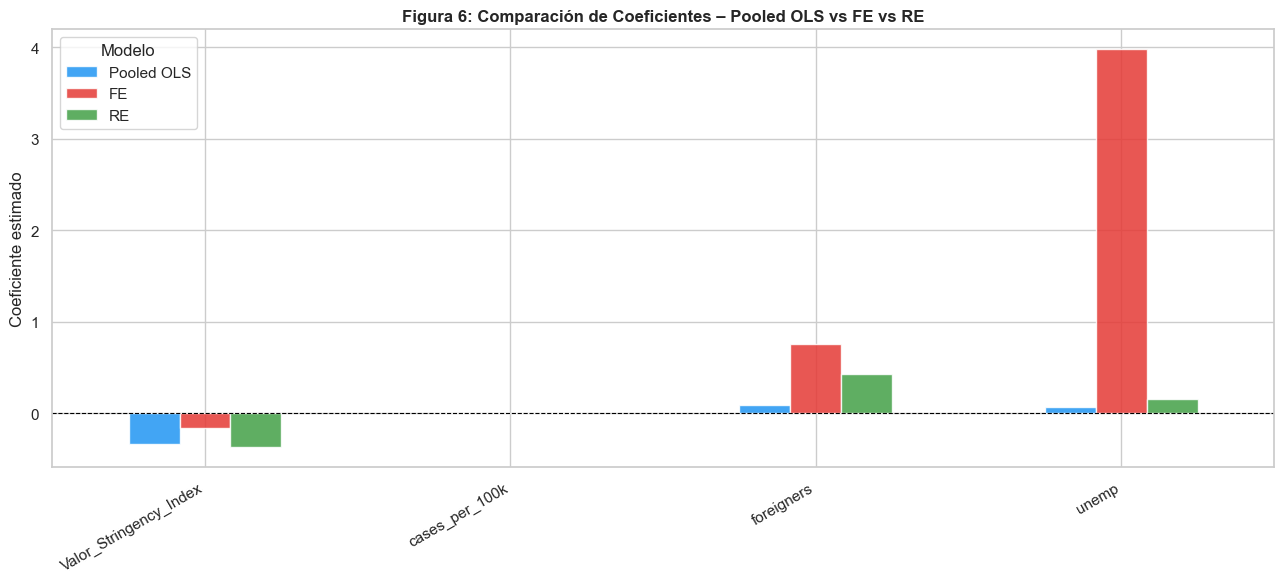

In [ ]:
# Visualización comparativa de coeficientes entre modelos

coef_df = pd.DataFrame({
    "Pooled OLS": pooled.params,
    "FE"        : fe.params,
    "RE"        : re.params,
}).drop("const", errors="ignore").dropna()

ax = coef_df.plot(kind="bar", figsize=(13, 6), color=["#2196F3","#E53935","#43A047"],
                  edgecolor="white", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Figura 6: Comparación de Coeficientes – Pooled OLS vs FE vs RE", fontsize=12, fontweight="bold")
ax.set_ylabel("Coeficiente estimado")
plt.xticks(rotation=30, ha="right"); plt.legend(title="Modelo")
plt.tight_layout(); plt.show()

### Resultados pregunta 5

#### Diferencias entre modelos

Los tres modelos coinciden en que las restricciones gubernamentales reducen la movilidad laboral, pero difieren significativamente en la magnitud estimada:

| Modelo | Coef. Stringency | Coef. unemp | R² within |
|--------|-----------------|-------------|----------|
| Pooled OLS | −0.340 | 0.073 | 0.293 |
| Efectos Fijos | −0.158 | 3.975 | 0.190 |
| Efectos Aleatorios | −0.371 | 0.160 | 0.296 |

La diferencia está en cómo cada modelo trata la heterogeneidad entre ciudades (αᵢ):

- **OLS y RE** usan variación entre y dentro de las ciudades. Mezclan el efecto causal de las políticas con diferencias estructurales permanentes (cultura de presencialidad, tipo de transporte, etc.). Por eso sobreestiman el efecto del Stringency

- **FE** elimina αᵢ restando la media de cada ciudad, aislando solo la variación temporal dentro de cada ciudad. El coeficiente baja a −0.16, limpiando el sesgo por variables omitidas permanentes.

El caso del desempleo lo muestra, en OLS y RE es casi nulo, pero en FE sube a 3.975. Esto pasa porque FE capta el efecto temporal del desempleo (en períodos de más desempleo, los que trabajan van más a la oficina por inseguridad), mientras que los otros modelos lo mezclan con diferencias estructurales entre ciudades.

#### Test de Hausman y modelo preferido

El Test de Hausman arroja χ²(5) = 2877.8 (p < 0.001), rechazando que αᵢ sea independiente de los regresores, lo que dice que solo el modelo de Efectos Fijos es consistente.

El modelo más adecuado es el FE con efectos de tiempo, por tres razones:
1. Es el único estimador consistente tras el rechazo del Test de Poolabilidad y del Test de Hausman.
2. Controla shocks pandémicos globales (olas, vacunación) que afectaron a todas las ciudades simultáneamente.
3. Aísla el efecto local de cada política, separándolo de la tendencia temporal común a toda Europa.

#### Variables robustas a la especificación

`Valor_Stringency_Index` y `cases_per_100k` son significativas y con el mismo signo en los tres modelos, siendo las únicas verdaderamente robustas. `foreigners` es significativa en FE y RE pero no en OLS. `unemp` y `age_dependency` muestran alta sensibilidad entre modelos, por lo que no son robustas.


## Pregunta 6: Modelo de Efectos Aleatorios Correlacionados (CRE – Mundlak)

*Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?*

**Modelo CRE:**
$$y_{it} = \alpha + X_{it}\beta + \bar{X}_i\gamma + (\nu_i + \varepsilon_{it})$$

Los términos $\bar{X}_i$ (media por ciudad de cada regresor) modelan explícitamente la correlación entre αᵢ y los regresores.

**Propiedades:** (1) β idénticos al FE. (2) γ testa correlación αᵢ–regresor. (3) Si γ ≠ 0 → RE simple sesgado.

In [ ]:
# Enfoque Mundlak: Agregar medias por entidad para variables independientes clave

panel_cre = panel_clean.copy()
entity_means = panel_cre[indep_vars].groupby(level=0).transform("mean")
mean_cols = {v: v+"_mean" for v in indep_vars}
entity_means = entity_means.rename(columns=mean_cols)
panel_cre = pd.concat([panel_cre, entity_means], axis=1)
print("Términos Mundlak agregados:")
print([c for c in panel_cre.columns if c.endswith("_mean")])

Términos Mundlak agregados:
['Valor_Stringency_Index_mean', 'cases_per_100k_mean', 'unemp_mean', 'age_dependency_mean', 'foreigners_mean']


In [22]:
# Definimos las variables dinámicas
time_varying_vars = ["Valor_Stringency_Index", "cases_per_100k"]

panel_cre = panel_clean.copy()

# Calculamos las media de cada variable dinámica por entidad (ciudad) para los términos de Mundlak
entity_means = panel_cre[time_varying_vars].groupby(level=0).transform("mean")
mean_cols = {v: v+"_mean" for v in time_varying_vars}
entity_means = entity_means.rename(columns=mean_cols)

# Agregamos los términos de Mundlak al panel
panel_cre = pd.concat([panel_cre, entity_means], axis=1)

print("Términos Mundlak agregados correctamente:")
print(list(mean_cols.values()))

# Definimos las columnas a usar y corremos el modelo CRE
cre_vars = indep_vars + list(mean_cols.values())

X_cre = panel_cre[cre_vars].dropna()
y_cre = panel_cre.loc[X_cre.index, dep_var]
X_cre = sm.add_constant(X_cre)

model_cre = lmp.RandomEffects(y_cre, X_cre)
cre = model_cre.fit(cov_type="robust")
print(cre)

Términos Mundlak agregados correctamente:
['Valor_Stringency_Index_mean', 'cases_per_100k_mean']
                        RandomEffects Estimation Summary                        
Dep. Variable:         workplaces_raw   R-squared:                        0.2977
Estimator:              RandomEffects   R-squared (Between):              0.4442
No. Observations:                6580   R-squared (Within):               0.2965
Date:                Fri, May 29 2026   R-squared (Overall):              0.3086
Time:                        02:19:53   Log-likelihood                -2.612e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      397.91
Entities:                          47   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                  F(7,6572)
Min Obs:                       140.00                                           
Max Obs:    

In [ ]:
# Interpretación de los términos de Mundlak (γ)

mundlak_terms = [c for c in cre.params.index if c.endswith("_mean")]
print("=== Coeficientes Mundlak (γ) ===")
print("H0: γ = 0 para todos → RE simple válido")
mdf = pd.DataFrame({
    "Coeficiente": cre.params[mundlak_terms],
    "Std. Err.":   cre.std_errors[mundlak_terms],
    "P-valor":     cre.pvalues[mundlak_terms]
}).round(4)
print(mdf.to_string())
sig = mdf[mdf["P-valor"] < 0.05]
print(f"\n→ {len(sig)} término(s) significativos (p<0.05): {list(sig.index)}")
if not sig.empty:
    print("  Conclusión: el RE simple está sesgado para esas variables. FE (o CRE) es necesario.")
else:
    print("  Conclusión: RE simple podría ser válido.")

=== Coeficientes Mundlak (γ) ===
H0: γ = 0 para todos → RE simple válido
                             Coeficiente  Std. Err.  P-valor
Valor_Stringency_Index_mean       0.8419     0.1113   0.0000
cases_per_100k_mean               0.0000     0.0000   0.0051

→ 2 término(s) significativos (p<0.05): ['Valor_Stringency_Index_mean', 'cases_per_100k_mean']
  Conclusión: el RE simple está sesgado para esas variables. FE (o CRE) es necesario.


### Resultados Efectos Aleatorios Correlacionados CRE 


El coeficiente del Stringency Index es −0.374, muy parecido al de RE, lo que confirma la propiedad teórica del CRE, los coeficientes β within convergen a los del FE cuando se modelan correctamente las medias.

**Términos Mundlak (γ):**

- `Valor_Stringency_Index_mean` = 0.842 (p < 0.001): ciudades que en promedio tuvieron restricciones más altas también presentan mayor movilidad laboral estructural. Este resultado podría reflejar que las ciudades que pusieron mayor regla tenían mayor actividad económica, o estaban más desarrolladas y eran más cuidadosas, por lo que tenían más trabajo y más movilidad laboral de por sí.

- `cases_per_100k_mean` = 4.4×10⁻⁶ (p = 0.005): la carga epidémica media entre ciudades tiene efecto positivo sobre la movilidad.

Ambos términos son altamente significativos, lo que confirma que αᵢ está correlacionado con las variables. Por lo tanto, el RE simple es sesgado y justifica el uso de FE o CRE.

**¿Es el CRE adecuado para modelar el componente no observado?** Sí, parcialmente. Permite estimar el efecto de variables estructurales invariantes  y cuantificar el sesgo del RE a través de los términos γ. Pero como no incluye efectos de tiempo, el FE con efectos temporales sigue siendo mejor para identificar causalidad.

---
## Pregunta 7: Modelo Preferido e Inferencia General

Usando las respuestas anteriores:
*¿Qué modelo prefiere? ¿Qué se puede inferir sobre el efecto de las restricciones gubernamentales sobre la movilidad laboral?*

In [24]:
print("=== Tabla Resumen: Comparación de los 4 Modelos ===")
comparison_full = compare({
    "Pooled OLS"   : pooled,
    "Efec. Fijos"  : fe,
    "Efec. Aleato.": re,
    "CRE (Mundlak)": cre
})
print(comparison_full)

=== Tabla Resumen: Comparación de los 4 Modelos ===
                                              Model Comparison                                             
                                        Pooled OLS        Efec. Fijos      Efec. Aleato.      CRE (Mundlak)
-----------------------------------------------------------------------------------------------------------
Dep. Variable                       workplaces_raw     workplaces_raw     workplaces_raw     workplaces_raw
Estimator                                 PanelOLS           PanelOLS      RandomEffects      RandomEffects
No. Observations                              6580               6580               6580               6580
Cov. Est.                                   Robust             Robust             Robust             Robust
R-squared                                   0.2517             0.0215             0.2911             0.2977
R-Squared (Within)                          0.2927             0.1899             0.

### ¿Qué modelo prefiere?

El modelo de Efectos Fijos con efectos de tiempo.

Porque los tests anteriores (poolabilidad, Hausman, términos de Mundlak) mostraron que las ciudades son diferentes entre sí y que esas diferencias están correlacionadas con las restricciones. 

La inclusión de efectos de tiempo es clave ya que la pandemia es un shock global que evoluciona por olas y afecta a todas las ciudades simultáneamente, controlar por la tendencia temporal común permite aislar el impacto puro de la política local. Esto explica por qué el coeficiente del Stringency en FE (−0.158) es menor que en CRE (−0.374) ya que sin efectos de tiempo, parte de la tendencia pandémica global se atribuye erróneamente a la política.


### ¿Qué se puede inferir sobre el efecto de las restricciones gubernamentales?

Basándonos en el modelo de efectos fijos:

**1. Las restricciones sí redujeron la movilidad laboral.** por cada punto adicional en el índice de Stringency, la movilidad laboral cae 0.16 puntos porcentuales dentro de cada ciudad. Entonces las políticas cumplieron su objetivo de reducir la presencialidad en el trabajo.

**2. El efecto de las restricciones es más moderado de lo que aparentaba.** En modelos sin efectos de tiempo (OLS, RE, CRE), el efecto parecía enorme de alrededor de un -0,37, pero al aplicar efectos fijos de tiempo, la magnitud cae a −0.16, lo que indica que gran parte de la caída observada se debía a tendencias pandémicas globales compartidas por todas las ciudades, no solo a los decretos locales.

**3. El desempleo refuerza la presencialidad de quienes conservan su trabajo.** El coeficiente de `unemp` (3.975) revela que en períodos de mayor desempleo local, los trabajadores que mantienen su empleo incrementan su asistencia presencial, reflejando un efecto de inseguridad laboral.

---
## Pregunta 8: Control Sintético

*Es posible que los resultados anteriores tengan sesgo dado que la movilidad laboral y las restricciones son parte de un fenómeno dinámico en el tiempo. Se utiliza control sintético para estimar el efecto causal de las restricciones gubernamentales sobre la movilidad para una ciudad de elección (que no puede ser Zaragoza), identificando el período de tratamiento y los controles potenciales.
Defina las variables para calcular el control sintetico y discuta sus resultados*

Seleccioné **Nice** (Francia) que es una ciudad mediterránea con bastante turismo. El tratamiento es el confinamiento localizado del **26 de marzo de 2021**, que comenzó unos días antes del confinamiento nacional francés (3 de abril). Esto permite observar el efecto causal de la medida.

**Período de análisis:** semanas 1 a 140 (17 feb 2020 – 17 oct 2022). Tratamiento desde semana 58 (la del 26 de marzo). 58 semanas de pre‑tratamiento y 82 de seguimiento.

**Selección de controles**

Para evitar contaminación del contrafactual, se excluyo:
- Otras ciudades francesas que recibieron el mismo confinamiento nacional, violarían SUTVA
- Ciudades alemanas por datos de restricciones anómalos, como se vio al inicio

Los controles son 32 ciudades de España, Italia y Suecia.


In [25]:
print("=== Ciudades francesas disponibles ===")
ciudades_fr = df[df["country"]=="FR"][["CODE","NAME"]].drop_duplicates().sort_values("NAME")
print(ciudades_fr.to_string(index=False))

=== Ciudades francesas disponibles ===
  CODE        NAME
FR024C      Angers
FR005C    Bordeaux
FR020C       Dijon
FR026C        Lens
FR003C       Lille
FR004C   Marseille
FR011C Montpellier
FR025C    Mulhouse
FR007C      Nantes
FR008C        Nice
FR001C       Paris
FR010C       Rouen
FR009C  Strasbourg
FR015C      Toulon
FR013C       Tours


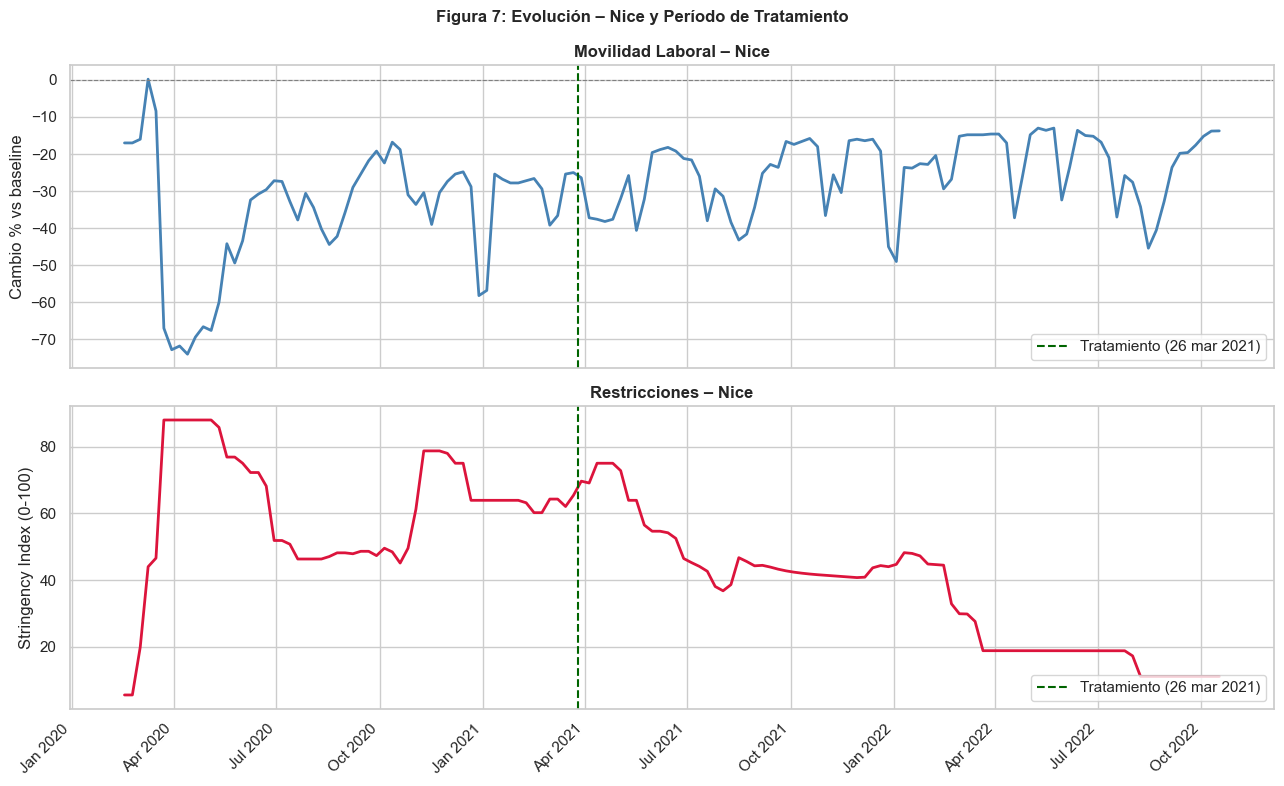

Semana de tratamiento (variable week): 58
Usar este valor como treatment_time en SynthControl.ipynb


In [ ]:
# Visualizar Nice: movilidad vs. restricciones para identificar el período de tratamiento
df_nice = df[df["NAME"].str.contains("Nice", case=False, na=False)].sort_values("date")

if df_nice.empty:
    print("Nice no encontrada. Usar el NAME exacto de la tabla anterior.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    axes[0].plot(df_nice["date"], df_nice["workplaces_raw"], color="steelblue", linewidth=2)
    axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axes[0].set_ylabel("Cambio % vs baseline"); axes[0].set_title("Movilidad Laboral – Nice", fontweight="bold")
    axes[1].plot(df_nice["date"], df_nice["Valor_Stringency_Index"], color="crimson", linewidth=2)
    axes[1].set_ylabel("Stringency Index (0-100)"); axes[1].set_title("Restricciones – Nice", fontweight="bold")
    treat_date = pd.Timestamp("2021-03-26")
    for ax in axes:
        ax.axvline(treat_date, color="darkgreen", linestyle="--", linewidth=1.5, label="Tratamiento (26 mar 2021)")
        ax.legend(loc="lower right")
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha="right")
    plt.suptitle("Figura 7: Evolución – Nice y Período de Tratamiento", fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()
    week_t = df_nice[df_nice["date"] <= treat_date]["week"].max()
    print(f"Semana de tratamiento (variable week): {week_t}")

In [ ]:
# librerías para control sintético

from pysyncon import Dataprep, Synth, AugSynth, PenalizedSynth
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Librerías para Control Sintético cargadas.')

Librerías para Control Sintético cargadas.


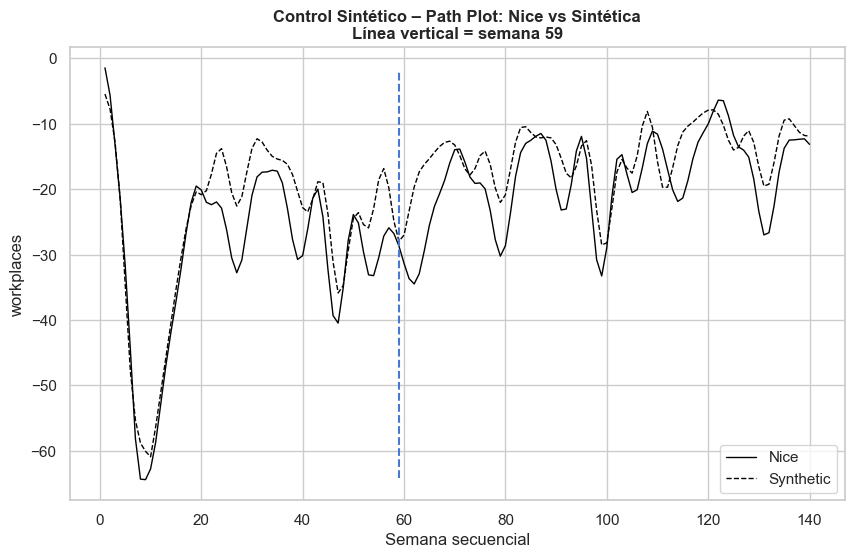

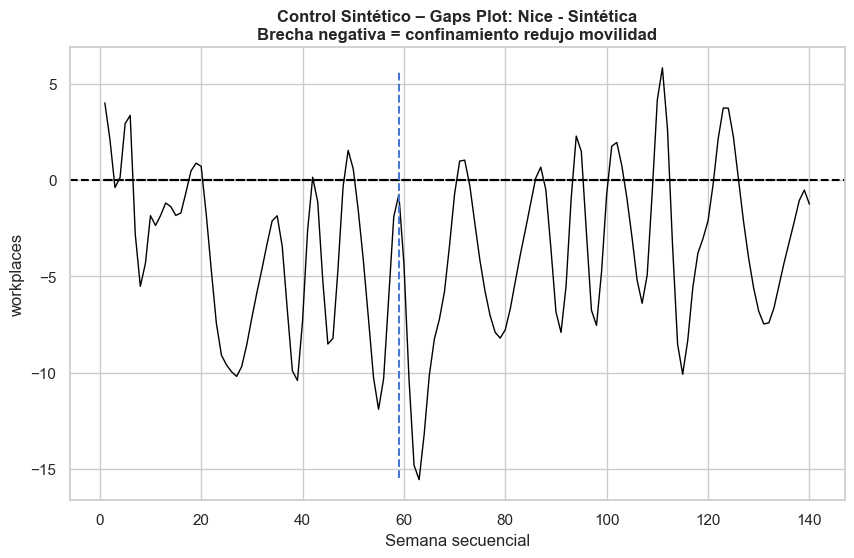

=== Resumen de ajuste pre-tratamiento ===


,treated,synthetic,sample mean
Population,462.846,460.042,842.438
agriculture,0.005,0.011,0.013
industry,0.064,0.128,0.114
construction,0.077,0.074,0.067
age_dependency,0.837,0.749,0.660


In [ ]:
# EJECUCIÓN COMPLETA DEL CONTROL SINTÉTICO

# 1. Asegurar nombre exacto y controles
nombres_nice = df[df['NAME'].str.contains('Nice', case=False, na=False)]['NAME'].unique()
nombre_exacto_nice = nombres_nice[0] if len(nombres_nice) > 0 else 'Nice'
ciudades_control = df[(df['country'].isin(['ES', 'IT', 'SE'])) & (df['NAME'] != nombre_exacto_nice)]['NAME'].unique().tolist()

# 2. Extraer semanas de tratamiento
nice_data = df[df['NAME'] == nombre_exacto_nice].sort_values('date')
treat_week = int(nice_data[nice_data['date'] >= pd.Timestamp('2021-03-26')]['week'].min())
pre_treat_start = int(nice_data['week'].min())

# 3. Configuración Dataprep con predictores demográficos
dataprep = Dataprep(
    foo=df,
    predictors=['Population', 'agriculture', 'industry', 'construction', 'age_dependency'],
    predictors_op='mean',
    time_predictors_prior=range(pre_treat_start, treat_week),
    dependent='workplaces',
    unit_variable='NAME',
    time_variable='week',
    treatment_identifier=nombre_exacto_nice,
    controls_identifier=ciudades_control,
    time_optimize_ssr=range(pre_treat_start, treat_week)
)

# 4. Ajuste del modelo
pen = PenalizedSynth()
pen.fit(dataprep, lambda_=0.001)

# 5. Path Plot
plt.figure(figsize=(10, 6))
plt.title(f'Control Sintético – Path Plot: {nombre_exacto_nice} vs Sintética\nLínea vertical = semana {treat_week}', fontsize=12, fontweight='bold')
plt.xlabel('Semana secuencial')
plt.ylabel('Movilidad Laboral')
pen.path_plot(time_period=range(pre_treat_start, int(df['week'].max()) + 1), treatment_time=treat_week)

# 6. Gaps Plot
plt.figure(figsize=(10, 6))
plt.title(f'Control Sintético – Gaps Plot: {nombre_exacto_nice} - Sintética\nBrecha negativa = confinamiento redujo movilidad', fontsize=12, fontweight='bold')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Semana secuencial')
plt.ylabel('Brecha (Real - Sintética)')
pen.gaps_plot(time_period=range(pre_treat_start, int(df['week'].max()) + 1), treatment_time=treat_week)

# 7. Resumen de pesos y métricas de ajuste
print('=== Resumen de ajuste pre-tratamiento ===')
pen.summary()



### Discusión de Resultados del Control Sintético


#### Composición del control sintético

Como Niza es una ciudad con turismo los predictores usados fueron `Population`, `agriculture`, `industry`, `construction` y `age_dependency`. Los elegí porque reflejan el tamaño, la actividad económica y la estructura demográfica de Niza, factores estables durante la pandemia que ayudan a construir un contrafactual creíble.

El `PenalizedSynth` (λ=0.001) asignó pesos no nulos solo a dos ciudades:

| Ciudad | País | Peso |
|--------|------|------|
| Génova | Italia | **66.8%** |
| A Coruña | España | **33.2%** |

Esto tiene sentido porque Génova (Italia) comparte con Nice su carácter de ciudad portuaria mediterránea con economía orientada a servicios y turismo. A Coruña (España), aunque no es mediterránea, aporta compatibilidad en tamaño poblacional y en actividad constructiva.


**Métricas de ajuste pre-tratamiento:**

- MAE (error absoluto medio): 4.49 puntos porcentuales

- MAPE (error porcentual absoluto medio): 21.1%

- Brecha media (Real – Sintético): −3.9 pp esto indica que Nice se movía un poco menos que su sintético incluso antes del tratamiento.

El ajuste no es perfecto, pero es aceptable. Este sesgo debe considerarse al interpretar los efectos causales.


#### Evolución y efecto del confinamiento

El gráfico de movilidad y restricciones muestra que la movilidad cae bruscamente justo después del 26 de marzo de 2021. El Path Plot  compara Niza con su sintético, el Gaps Plot muestra la diferencia (Real – Sintético).

- **Pico de impacto:** semana 63 (26 de abril de 2021), la brecha llega a −15.6 pp (movilidad real −32.9% vs. sintético −17.4%).  
  Descontando el sesgo pre‑existente (−3.9 pp), el efecto neto del confinamiento es de aproximadamente −12 pp.

- **Recuperación:** al levantar el confinamiento nacional el 19 de mayo, la brecha se reduce rápido. En la semana 70 (14 de junio) ya está en −0.7 pp, prácticamente cerrada.

- **Período largo:** la brecha oscila entre positiva y negativa, con medias decrecientes. Las caídas en verano coinciden con vacaciones más largas en Francia; los repuntes en otoño‑invierno reflejan nuevas olas (Delta, Ómicron)


#### Consistencia con los modelos de panel

El Control Sintético confirma y complementa los hallazgos de las preguntas 2 a la 7:

- **Dirección:** negativa en ambos enfoques 

- **Magnitud:** el FE estimó −0.16 pp por punto de Stringency Index (promedio a lo largo de toda la pandemia y todas las ciudades). En el episodio de Nice el Stringency subió ~30 puntos, proyectando un efecto FE de ~5 pp. La brecha observada de hasta 15 pp es mayor porque incluye el shock directo de un cierre total que supera lo capturado por el índice continuo.
- **Causalidad:** El Gaps Plot muestra que la brecha crece justo la semana que empezó el confinamiento. Eso es una prueba clara de que el confinamiento causó la caída. El FE, en cambio, solo da un promedio y no puede ver ese momento exacto.


#### Limitaciones y posibles extensiones

- El MAPE del 21% indica que el ajuste antes del tratamiento no es perfecto, por lo que se podría probar con otros valores de λ o agregar más variables de tendencia pre-pandemia.
- No de realizaron tests de placebo como por ejemplo, reasignar el tratamiento a otras ciudades, lo que ayudaría a ver si el efecto que vemos en Niza es realmente especial o no.
- El inicio del tratamiento en Nice (26 mar) y el nacional de Francia (3 abr) están a solo una semana de distancia, lo que dificulta aislar el efecto del decreto local del impacto del confinamiento nacional.
- Se usó `workplaces` en lugar de `workplaces_raw`, el efecto en escala no suavizada puede diferir en magnitud.


#### Conclusión

El Control Sintético valida causalmente la conclusión principal del trabajo. Nice experimentó una caída adicional de hasta **−15.6 pp** en movilidad laboral tras el confinamiento del 26 de marzo de 2021, efecto que se disipó en ~10 semanas tras el levantamiento de las medidas. Combinada con los estimadores consistentes del modelo de Efectos Fijos y el test de Hausman, esta evidencia permite concluir con alta confianza que las **restricciones gubernamentales causaron efectivamente la reducción de la movilidad laboral** durante la pandemia. 
